In [243]:
### 1. Setup and imports

from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from traitlets import Bool

In [244]:
### 2, 3 and 4: Problem Interface, Node class + helper functions

class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass


## Node and SearchResult class, as well as helper functions

@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost


def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [245]:
### 5. Implementing the Grid Search Problem

MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # Return True if state is equal to the goal state.
        return state == self.goal

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        l: List[str] = []

        for move, (x, y) in MOVES.items():
            # Computing the resulting coordinates for the current move
            computed = (x + state[0], y + state[1])

            # Setting bounds to use for check below (Co-ordinates are only valid if it's between
            # zero and the size of the grid, not just non-negative)
            x_in_bounds = 0 <= computed[0] < len(self.grid)
            y_in_bounds = 0 <= computed[1] < len(self.grid[0])

            # Checking for whether it is in bounds and the cell is free
            if x_in_bounds and y_in_bounds and self.grid[computed[0]][computed[1]] == 0:
                l.append(move) # add the action to the list


        return l



    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # Return the next state after applying action to state.
        dr, dc = MOVES[action]
        return state[0] + dr, state[1] + dc

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        return 1

In [246]:
### 5.1 Self-Check for GridProblem

test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")

GridProblem self-check passed.


In [247]:
### 6. Sample Drone Map

sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

startPoint = (0, 0)
goalPoint = (9, 9)

problem = GridProblem(sample_grid, startPoint, goalPoint)

In [248]:
### 7: Visualization helper

def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualize a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

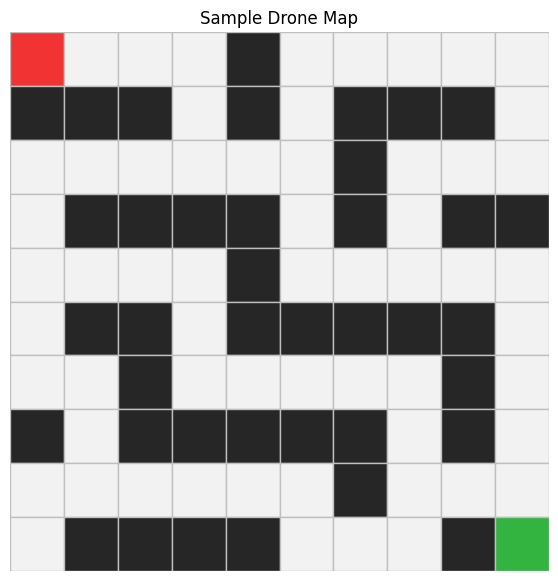

In [249]:
plot_path(sample_grid, startPoint, goalPoint, title="Sample Drone Map")

In [250]:
### 8: The Shared expand Method

class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, p: Problem, node: Node) -> Iterable[Node]:
        s = node.state

        for a in p.actions(s):
            s_prime = p.result(s, a)
            new_cost = node.path_cost + p.action_cost(s, a, s_prime)
            yield Node(s_prime, node, a, new_cost)


    @abstractmethod
    def search(self, p: Problem) -> SearchResult:
        pass

In [251]:
### 9: Breadth-First Search (BFS)

class BreadthFirstSearch(SearchAlgorithm):
    def search(self, p: Problem) -> SearchResult:
        algorithm = "BFS"

        sr = SearchResult(algorithm=algorithm, status='', solution=None, nodes_expanded=0, max_frontier_size=0, reached_count=0, limit=None, iterations=None)

        # Create the initial node from problem.initial_state()
        node = Node(state=p.initial_state())


        # If the initial state is the goal, return success (set the values and return sr)
        if p.is_goal(node.state):
            sr.solution = node
            sr.status = 'found'
            return sr

        frontier = deque([node])
        reached = set(p.initial_state())

        # We look through the frontier
        while not len(frontier) == 0:

            # We pop the node from the left of the deque and incerement nodes_expanded
            node = frontier.popleft()
            sr.nodes_expanded += 1

            # Expand it to get its children
            children = self.expand(p, node)

            for child in children:
                if p.is_goal(child.state):
                    sr.solution = node
                    sr.status = 'found'
                    return sr

                if not child.state in reached:
                    reached.add(child.state)
                    frontier.append(child)

            sr.max_frontier_size = max(sr.max_frontier_size, len(frontier))

        sr.status = 'failure'
        return sr

In [252]:
## 10. Depth-First Search (DFS)

class DepthFirstSearch(SearchAlgorithm):
    def search(self, p: Problem) -> SearchResult:
        algorithm = "DFS"

        sr = SearchResult(algorithm=algorithm, status='', solution=None, nodes_expanded=0, max_frontier_size=0, reached_count=0, limit=None, iterations=None)

        node = Node(state=p.initial_state())

        if p.is_goal(node.state):
            sr.solution = node
            sr.status = 'found'
            return sr

        frontier: List[Node] = [node]
        reached = set(p.initial_state())

        while not len(frontier) == 0:
            node = frontier.pop()
            sr.nodes_expanded += 1

            # Expand it to get its children
            children = self.expand(p, node)

            for child in children:
                if p.is_goal(child.state):
                    sr.solution = node
                    sr.status = 'found'
                    return sr

                if not child.state in reached:
                    reached.add(child.state)
                    frontier.append(child)

            sr.max_frontier_size = max(sr.max_frontier_size, len(frontier))

        sr.status = 'failure'
        return sr


# Extremely similar to BFS, just that this time we're using a stack (LIFO)
# instead of a deque (FIFO), and that's what causes the difference b/n the two.



In [253]:
## 11. Depth-Limited Search

class DepthLimitedSearch(SearchAlgorithm):
    def search(self, p: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            p=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(
        self,
        p: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:

        # TODO 8:
        # Implement recursive depth-limited search.
        #
        # Steps:
        # 1. If node.state is goal, return (node, "success").
        # 2. Else if node.depth >= limit, return (None, "cutoff").
        # 3. Otherwise:
        #       a. increment metrics["nodes_expanded"].
        #       b. set cutoff_occurred = False.
        #       c. for each child in expand(problem, node):
        #             i. skip the child if child.state already appears on the current path.
        #            ii. update max_stack_size.
        #           iii. recursively call _recursive_dls on the child.
        #            iv. if result is "success", return success immediately.
        #             v. if result is "cutoff", set cutoff_occurred = True.
        #       d. after all children:
        #             if cutoff_occurred, return (None, "cutoff")
        #             else return (None, "failure")

        cutoff_occurred: bool

        if p.is_goal(node.state):
            return node, 'success'
        elif node.depth >= limit:
            return None, "cutoff"

        metrics['nodes_expanded'] += 1
        cutoff_occurred = False


        for child in self.expand(p, node):
            if state_is_on_path(node, child.state):
                continue

            print(f"Comparing max stack size of {metrics['max_stack_size']} to current of {child.depth}")

            metrics['max_stack_size'] = max(metrics['max_stack_size'], child.depth)

            result, status = self._recursive_dls(p, child, limit, metrics, current_stack_size)

            if status == "success":
                return result, status
            elif status == "cutoff":
                cutoff_occurred = True

        if cutoff_occurred:
            return None, "cutoff"
        else:
            return None, "failure"


Comparing max stack size of 1 to current of 1
Comparing max stack size of 1 to current of 2
Comparing max stack size of 2 to current of 3
Comparing max stack size of 3 to current of 4
Comparing max stack size of 4 to current of 5
Comparing max stack size of 5 to current of 6
Comparing max stack size of 6 to current of 7
Comparing max stack size of 7 to current of 8
Comparing max stack size of 8 to current of 9
Comparing max stack size of 9 to current of 10
Comparing max stack size of 10 to current of 11
Comparing max stack size of 11 to current of 12
Comparing max stack size of 12 to current of 13
Comparing max stack size of 13 to current of 14
Comparing max stack size of 14 to current of 15
Comparing max stack size of 15 to current of 16
Comparing max stack size of 16 to current of 17
Comparing max stack size of 17 to current of 16
Comparing max stack size of 17 to current of 17
Comparing max stack size of 17 to current of 18
Comparing max stack size of 18 to current of 19
Comparing m

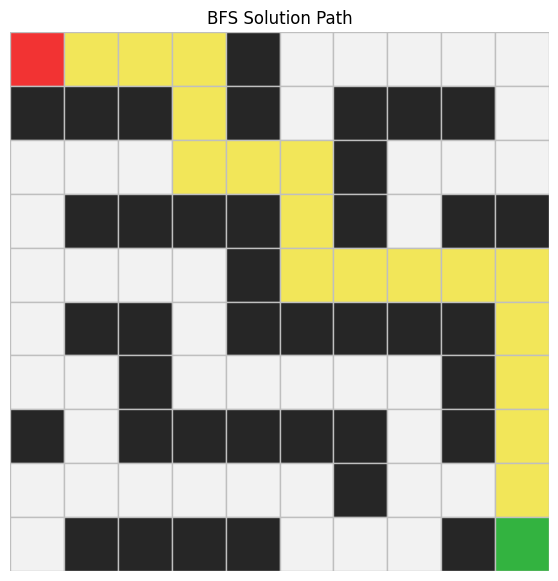

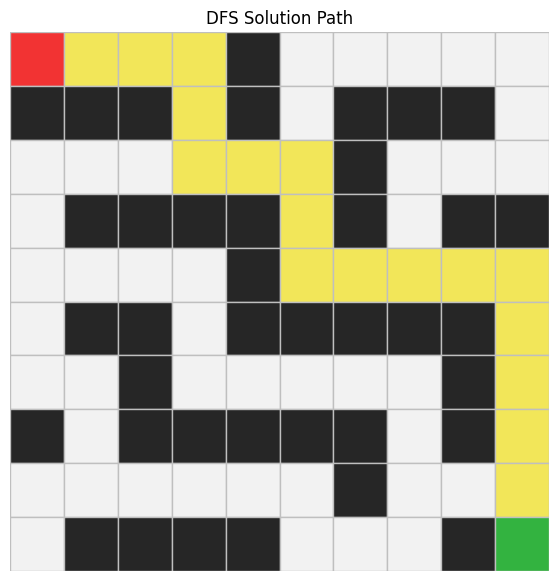

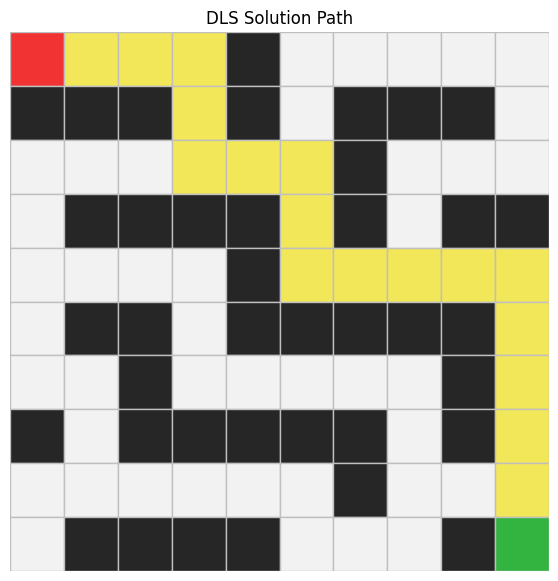

In [254]:
## 13. Running the algorithms on a sample map

bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=20),
    # ids.search(problem, max_depth=30),
]

show_results(results)

# Visualize it
bfs_result = results[0]
dfs_result = results[1]
dls_result = results[2]

plot_path(
    sample_grid,
    startPoint,
    goalPoint,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    startPoint,
    goalPoint,
    path=dfs_result.path,
    title="DFS Solution Path",
)

plot_path(
    sample_grid,
    startPoint,
    goalPoint,
    path=dls_result.path,
    title="DLS Solution Path",
)